# Masked AutoEncoder (MAE) from scratch

This is a WIP.

https://arxiv.org/abs/2111.06377

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import inspect
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from dataclasses import dataclass, asdict, replace
from typing import TypeAlias

In [2]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# count how many trainable weights the model has
def count_parameters(model) -> None:
    total_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of parameters: {total_params:,}')

# ViT Configurations

In [4]:
@dataclass
class BaseConfig:
    image_size:int= 224
    patch_size:int= 16
    channels:int= 3
    num_classes:int|None= 1000
    pool:str= 'cls'
    n_embed:int= 768
    n_layer:int= 12
    n_head:int= 12
    d_ff:int= (4 * n_embed)
    dropout:float= 0.1
    p_type:str|None= 'conv'
    fine_tune:bool= True


@dataclass
class SmallConfig(BaseConfig):
    n_embed:int= 512
    n_layer:int= 8
    n_head:int= 16
    d_ff:int= (4 * n_embed)


@dataclass
class LargeConfig(BaseConfig):
    n_embed:int= 1024
    n_layer:int= 24
    n_head:int= 16
    d_ff:int= (4 * n_embed)


@dataclass
class HugeConfig(BaseConfig):
    patch_size:int= 14
    n_embed:int= 1280
    n_layer:int= 32
    n_head:int= 16
    d_ff:int= (4 * n_embed)


ModelConfig:TypeAlias= SmallConfig | BaseConfig | LargeConfig | HugeConfig

# ViT Backbone

The following ViT code comes from vit.ipynb ( https://github.com/evortigosa/AI_devs/blob/main/vit.ipynb )  - with a few modifications -

In [5]:
class MultiHeadSelfAttention(nn.Module):
    """
    The Multi-Headed Self-Attention Layer.
    """

    def __init__(self, n_embed, n_head, dropout=0.1) -> None:
        super(MultiHeadSelfAttention, self).__init__()
        assert n_embed % n_head == 0, "n_embed must be divisible by n_head"
        self.n_embed= n_embed
        self.n_head = n_head
        self.d_head = n_embed // n_head
        # query, key, value projections in a single batch
        self.c_attn= nn.Linear(n_embed, 3 * n_embed)
        self.scaling= 1.0 / math.sqrt(self.d_head)
        # regularization
        self.dropout= nn.Dropout(p=dropout)
        # output projection
        self.o_proj= nn.Linear(n_embed, n_embed)


    def forward(self, x):
        B, T, C= x.size()  # x(batch_size, sequence length, n_embed)
        assert C== self.n_embed, "Input embedding dimension must match model embedding dimension"
        # 1. calculate query, key, values for all heads
        qkv= self.c_attn(x)
        q, k, v= qkv.split(self.n_embed, dim=2) # q,k,v -> (B, T, C)
        # 2. reshape for Multi-Head Attention
        q= q.view(B, -1, self.n_head, self.d_head).transpose(1, 2)  # q,k,v view   -> (B, T, nh, dh)
        k= k.view(B, -1, self.n_head, self.d_head).transpose(1, 2)  # q,k,v transp -> (B, nh, T, dh)
        v= v.view(B, -1, self.n_head, self.d_head).transpose(1, 2)

        # 3. Attention - the 'scaled dot product'
        #"""
        attn= (q @ k.transpose(-2, -1)) * self.scaling
        # normalize Attention scores
        attn= F.softmax(attn, dim=-1)
        attn= self.dropout(attn)
        # 4. compute Attention output
        y= attn @ v  # (B, nh, T, dh)
        """
        # and the following implements FlashAttention
        y= F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout.p, is_causal=False)
        #"""

        # 5. concatenate multi-head outputs -- re-assembly all head outputs side by side
        y= y.transpose(1, 2).contiguous().view(B, T, C)
        # 6. output projection
        return self.o_proj(y)


In [6]:
class FeedForward(nn.Module):
    """
    The Feed-Forward Network (FFN).
    """

    def __init__(self, n_embed, d_ff, dropout=0.1) -> None:
        super(FeedForward, self).__init__()
        self.fc1  = nn.Linear(n_embed, d_ff)
        self.activ= nn.GELU()
        self.dropout= nn.Dropout(p=dropout)
        self.fc2  = nn.Linear(d_ff, n_embed)


    def forward(self, x):
        x= self.fc1(x)
        x= self.activ(x)
        x= self.dropout(x)

        return self.fc2(x)


In [7]:
class EncoderBlock(nn.Module):
    """
    The Ecoder Block (pre-normalization version).
    """

    def __init__(self, n_embed, n_head, d_ff, dropout=0.1) -> None:
        super(EncoderBlock, self).__init__()

        self.norm1= nn.LayerNorm(n_embed)
        self.attn= MultiHeadSelfAttention(n_embed, n_head, dropout)
        self.dropout1= nn.Dropout(p=dropout)

        self.norm2= nn.LayerNorm(n_embed)
        self.ffn= FeedForward(n_embed, d_ff, dropout)
        self.dropout2= nn.Dropout(p=dropout)


    def forward(self, x):
        x_norm= self.norm1(x)
        x= x + self.dropout1(self.attn(x_norm))

        x_norm= self.norm2(x)
        x= x + self.dropout2(self.ffn(x_norm))

        return x


In [8]:
class TransformerEncoder(nn.Module):
    """
    The Transformer Encoder is essentially a stack of N Encoder Blocks.
    """

    def __init__(self, n_embed=512, n_layer=6, n_head=8, d_ff=2048, dropout=0.1) -> None:
        super(TransformerEncoder, self).__init__()
        self.transformer= nn.ModuleList([
            EncoderBlock(n_embed, n_head, d_ff, dropout) for _ in range(n_layer)
        ])
        self.ln_final= nn.LayerNorm(n_embed)


    def forward(self, x):
        for block in self.transformer:
            x= block(x)

        return self.ln_final(x)


In [9]:
class PatchEmbedding(nn.Module):
    """
    Initializes the Images to Patch Embeddings module.
    """

    def __init__(self, patch_height, patch_width, channels, n_embed, p_type='conv') -> None:
        super(PatchEmbedding, self).__init__()
        # calculate the dimension of each patch
        ph, pw= patch_height, patch_width
        patch_dim= channels * ph * pw

        # The original ViT uses a linear layer for patch embedding
        if p_type== 'linear':
            # unfold images of shape (batch_size, channels, image_height, image_width)
            # into patches of shape  (batch_size, num_patches, patch_dim)
            self.projection= nn.Sequential(
                Rearrange('b c (h ph) (w pw) -> b (h w) (ph pw c)', ph=ph, pw=pw),
                nn.Linear(patch_dim, n_embed), # project patches to embedding dimension
            )  # embedding shape (batch_size, num_patches, n_embed)
        else:
            # Hugging Face's ViT uses a convolutional layer for patch embedding
            # apply Conv2d to split image into patches and project
            self.projection= nn.Sequential(    # (batch_size, n_embed, H/ph, W/pw)
                nn.Conv2d(channels, n_embed, kernel_size=(ph, pw), stride=(ph, pw)),
                nn.Flatten(start_dim=2),       # (batch_size, n_embed, num_patches)
                Rearrange('b e p -> b p e'),   # (batch_size, num_patches, n_embed)
            )


    def forward(self, img):
        x= self.projection(img)

        return x


In [10]:
class Embedding(nn.Module):
    """
    Initializes the Embedding module.
    """

    def __init__(self, image_size, patch_size, channels, n_embed, dropout=0.1, p_type='conv') -> None:
        super(Embedding, self).__init__()
        self.image_size= int(image_size)
        self.patch_size= int(patch_size)

        image_height, image_width= self.pair(self.image_size)
        patch_height, patch_width= self.pair(self.patch_size)
        # ensure that the image dimensions are divisible by the patch sizes
        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            'Image dimensions must be divisible by the patch size.'
        # calculate the number of patches
        self.num_patches= int((image_height // patch_height) * (image_width // patch_width))

        # define the patch embedding
        self.patch_embed= PatchEmbedding(patch_height, patch_width, channels, n_embed, p_type)
        # define CLS token and positional embeddings -- both as learnable parameters
        self.cls_token= nn.Parameter(torch.randn(1, 1, n_embed))
        self.pos_embed= nn.Parameter(torch.randn(1, self.num_patches + 1, n_embed))

        # apply layer normalization and dropout
        self.norm= nn.LayerNorm(n_embed)
        self.dropout= nn.Dropout(p=dropout)

        # initialize CLS token and positional embedding with small normal distributions
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)


    def pair(self, x):
        """
        Utility function: Converts a single value into a tuple of two values.
        If x is already a tuple, it is returned as is.
        """
        return x if isinstance(x, tuple) else (x, x)


    def forward(self, img):
        x= self.patch_embed(img)
        B, P, C= x.size()  # (batch_size, num_patches, n_embed)
        # repeat class token (CLS) for each image in the batch
        cls_token= repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        # concatenate class token (CLS) with patch embeddings
        x= torch.cat((cls_token, x), dim=1)
        # add positional embedding to the input
        x += self.pos_embed  # (batch_size, num_patches + 1, n_embed)

        return self.dropout(self.norm(x))


In [11]:
class MLPHead(nn.Module):
    """
    The MLP (classification) head.
    """

    def __init__(self, n_embed, d_ff, num_classes, dropout=0.1, fine_tune=False) -> None:
        super(MLPHead, self).__init__()
        if fine_tune:
            self.c_head= nn.Linear(n_embed, num_classes)
        else:
            self.c_head= nn.Sequential(
                nn.Linear(n_embed, d_ff),
                nn.GELU(),
                nn.Dropout(p=dropout),
                nn.Linear(d_ff, num_classes),
            )


    def forward(self, x):
        x= self.c_head(x)

        return x


In [12]:
class ViT(nn.Module):
    """
    Initializes a Vision Transformer (ViT) model.
    - num_classes (int | None): defines the number of output logits (classification head).
    - pool (str): defines the pooling strategy to the final head; 'cls' (CLS token), 'mean' (global average
    pooling over patch tokens), or 'feature' (the full per-patch feature map, used by the decoder).
    - p_type (str | None): defines the input embedding type ('linear' or 'conv'); None sets an identity layer
    for external embedding modules.
    """

    def __init__(self, image_size:int, patch_size:int, channels:int, num_classes=None, pool='cls', n_embed=512,
                 n_layer=6, n_head=8, d_ff=2048, dropout=0.1, p_type='conv', fine_tune=False) -> None:
        super(ViT, self).__init__()
        # ensure the pooling strategy is valid
        assert pool in {'cls', 'mean', 'feature'}, "Pool must be 'cls', 'mean', or 'feature'."
        # pooling strategy ('cls' token, 'mean' (GAP over patches), or full 'feature' map)
        self.pool= pool

        # define the patch, CLS token, and positional embeddings
        self.embedding= Embedding(
            image_size, patch_size, channels, n_embed, dropout, p_type
        ) if p_type is not None else nn.Identity()
        # define the transformer encoder
        self.encoder= TransformerEncoder(n_embed, n_layer, n_head, d_ff, dropout)

        # identity layer (no change to the tensor)
        self.latent_space= nn.Identity()
        # classification head
        self.lm_head= MLPHead(n_embed, d_ff, num_classes, dropout, fine_tune) if num_classes is not None else None


    @classmethod
    def from_config(cls, cfg):
        cfg_map= asdict(cfg)
        # filter to only accept parameters that __init__ accepts
        sig= inspect.signature(cls.__init__)
        valid= set(sig.parameters) - {"self"}
        filtered= {k: v for k, v in cfg_map.items() if k in valid}

        return cls(**filtered)


    def forward(self, img):
        # img(batch_size, channels, image_height, image_width)
        x= self.embedding(img)  # x(batch_size, num_patches + 1, n_embed)
        # forward the embedding through the transformer encoder
        x= self.encoder(x)

        # extract class token and feature map
        cls_token  = x[:, 0]
        feature_map= x[:, 1:]

        logits= None
        if self.lm_head is not None:
            # apply pooling operation:
            #  'cls'     -> the CLS token
            #  'mean'    -> global average pooling over patch tokens (MAE-paper fine-tuning); excludes CLS
            #  'feature' -> the full per-patch feature map (used by the MAE decoder's pixel head)
            if self.pool == 'cls':
                pool_output= cls_token
            elif self.pool == 'mean':
                pool_output= feature_map.mean(dim=1)
            else:
                pool_output= feature_map
            # apply the identity transformation (no change to the tensor)
            pool_output= self.latent_space(pool_output)
            # forward the classifier
            logits= self.lm_head(pool_output)

        # return CLS token, patch embeddings, and classification results
        return logits, feature_map, cls_token


# MAE Input Modules

In [13]:
class PatchMaskingMAE(nn.Module):
    """
    Random masking of patch embeddings for the MAE encoder side (self-supervised pretraining).
    Only the visible (kept) patches are returned to feed the encoder -- this is the efficiency
    trick of MAE: the heavy encoder only ever sees ~25% of the tokens.
    - If has_cls_tk=True, the CLS token (first token) is never masked nor shuffled.
    Adapted from https://arxiv.org/abs/2111.06377
    """

    def __init__(self, mask_ratio=0.75, has_cls_tk=False) -> None:
        super(PatchMaskingMAE, self).__init__()
        assert 0.0 <= mask_ratio < 1.0, "mask_ratio must be in [0, 1)"
        self.mask_ratio= mask_ratio
        self.has_cls_tk= has_cls_tk


    def extra_repr(self):
        return f"mask_ratio={self.mask_ratio}, cls_token={self.has_cls_tk}"


    def forward(self, x):
        """
        Masking is a pretraining-only trick. After pretraining the encoder is fine-tuned / evaluated
        on the full input (mask_ratio=0), so we add a fast path for that case.
        """
        cls= None
        if self.has_cls_tk:
            # ensure the class token will not be masked -- keep the token dimension (slice :1)
            cls= x[:, :1, :]
            x  = x[:, 1:, :]

        B, P, C= x.size()  # (batch_size, num_patches, n_embed)
        # ---- fast path: nothing to mask (fine-tuning / inference) ----
        if self.mask_ratio == 0.0:
            mask= torch.zeros(B, P, device=x.device, dtype=x.dtype)
            ids_restore= torch.arange(P, device=x.device).unsqueeze(0).repeat(B, 1)
            x_masked= x if cls is None else torch.cat((cls, x), dim=1)

            return x_masked, mask, ids_restore

        # ---- general path: random per-sample masking ----
        # determine the number of patches to keep
        pto_keep= int(P * (1 - self.mask_ratio))
        # generate random indices for masking -- noise in [0, 1]
        # ascend: small noise -> keep, large noise -> remove
        ids_shuffle= torch.rand(B, P, dtype=x.dtype, device=x.device).argsort(dim=1)
        ids_restore= torch.argsort(ids_shuffle, dim=1)

        # gather the first subset of the shuffled patches (the "visible" ones)
        ids_keep= ids_shuffle[:, :pto_keep]
        x_masked= torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, C))
        if cls is not None:
            x_masked= torch.cat((cls, x_masked), dim=1)

        # generate the binary mask: 0 is keep, 1 is to remove
        mask= torch.ones([B, P], device=x.device)
        mask[:, :pto_keep]= 0
        # unshuffle to get the binary mask
        mask= torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore


In [14]:
class EmbeddingDecoderMAE(nn.Module):
    """
    Builds the decoder input for a Masked Autoencoder (MAE). The encoder only emitted the visible
    tokens, so here we (1) project them to the decoder width, (2) re-insert a learnable mask token
    at every removed position, (3) unshuffle everything back to the original order, and (4) add
    decoder positional embeddings.
    - If has_cls_tk=True, x carries a CLS token as its first token; False otherwise.
    Adapted from https://arxiv.org/abs/2111.06377
    """

    def __init__(self, enc_n_embed, dec_n_embed, num_patches, has_cls_tk=False, bias=False) -> None:
        super(EmbeddingDecoderMAE, self).__init__()
        self.has_cls_tk= has_cls_tk
        # map encoder width to decoder width (identity if they already match)
        self.decoder_embed= (
            nn.Linear(enc_n_embed, dec_n_embed, bias=bias) if enc_n_embed != dec_n_embed else nn.Identity()
        )
        # learnable mask token for masked patches -- broadcast to every removed position
        self.mask_token= nn.Parameter(torch.zeros(1, 1, dec_n_embed))
        # positional embeddings for the decoder tokens
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dec_n_embed))

        # initialize mask_token and positional embeddings with small normal distributions
        nn.init.normal_(self.mask_token, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_embed,  mean=0.0, std=0.02)


    def extra_repr(self):
        return f"cls_token={self.has_cls_tk}"


    def forward(self, x, ids_restore, cls_token=None):
        """
        - cls_token (optional): an external CLS token not yet attached to x.
        """
        # local flag: whether the working sequence carries a CLS token at position 0
        has_cls= self.has_cls_tk
        if (not has_cls) and (cls_token is not None):
            # the input x does not have a CLS token but we provide it in cls_token
            x= torch.cat([cls_token.unsqueeze(1), x], dim=1)  # prepend cls token
            has_cls= True

        # project visible tokens to decoder n_embed
        x= self.decoder_embed(x)
        # append mask tokens to sequence. The count is exactly the number of masked patches
        n_mask= ids_restore.shape[1] + int(has_cls) - x.shape[1]
        mask_tokens= self.mask_token.repeat(x.shape[0], n_mask, 1)

        if has_cls:
            # temporarily remove the cls token while we unshuffle patches
            x_= torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        else:
            x_= torch.cat([x, mask_tokens], dim=1)
        # unshuffle: scatter visible + mask tokens back to their original patch positions
        x_= torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))

        if has_cls:
            # append cls token from the input
            x= torch.cat([x[:, :1, :], x_], dim=1)
            return x + self.pos_embed

        return x_ + self.pos_embed


# Building the MAE

In [15]:
class MAE(nn.Module):
    """
    Initializes a Masked Autoencoder with ViT backbone (asymmetric encoder/decoder).
    - encoder_config and decoder_config are dataclass objects to initialize the backbone.
    """

    def __init__(self, image_size:int, patch_size:int, channels:int, mask_ratio:float,
                 encoder_config:ModelConfig, decoder_config:ModelConfig, norm_pix_loss=False) -> None:
        super(MAE, self).__init__()
        self.channels= int(channels)
        assert 0.0 < mask_ratio < 1.0, "mask_ratio must be in (0, 1)"

        # --------------------------------------------------------------------------
        # MAE encoder side: patch embedding and mask layer
        self.encoder_embed= Embedding(
            image_size, patch_size, self.channels, encoder_config.n_embed, encoder_config.dropout,
            encoder_config.p_type
        )
        self.mask_layer= PatchMaskingMAE(mask_ratio, has_cls_tk=True)

        # the encoder receives already-embedded tokens, so p_type=None (embedding = Identity),
        # and num_classes=None (no head during pretraining)
        enc_overrides= {
            "image_size": image_size, "patch_size": patch_size, "channels": self.channels,
            "p_type": None, "num_classes": None, "pool": 'cls',
        }
        self.encoder= ViT.from_config(replace(encoder_config, **enc_overrides))
        # --------------------------------------------------------------------------

        # --------------------------------------------------------------------------
        # MAE decoder side: expand embedding + pos_embed
        self.decoder_embed= EmbeddingDecoderMAE(
            encoder_config.n_embed, decoder_config.n_embed, self.encoder_embed.num_patches,
            has_cls_tk=True, bias=True
        )
        # (patch_size**2 * self.channels) represents pixel values per patch for decoder reconstruction
        dec_overrides= {
            "image_size": image_size, "patch_size": patch_size, "channels": self.channels,
            "p_type": None, "num_classes": int(patch_size**2 * self.channels), "pool": 'feature',
        }
        self.decoder= ViT.from_config(replace(decoder_config, **dec_overrides))
        # --------------------------------------------------------------------------

        self.norm_pix_loss= norm_pix_loss

        # initialize Linear and Conv2d modules with Xavier / fan_avg
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                if isinstance(m, (nn.Linear, nn.Conv2d)) and m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.zeros_(m.bias)


    def set_mask_ratio(self, mask_ratio=0.75) -> None:
        assert 0.0 <= mask_ratio < 1.0, "mask_ratio must be in [0, 1)"
        self.mask_layer.mask_ratio= float(mask_ratio)


    def patchify(self, img):
        """
        Non-learnable patch method. The input image is divided into patches and flattened with no learnable
        parameters like in the Embedding module.
        img: (B, C, H, W)
        x:   (B, P, patch_size**2*C)
        """
        B, C, H, W= img.size()
        ph= self.encoder_embed.patch_size
        pw= self.encoder_embed.patch_size
        assert H % ph == 0 and W % pw == 0, \
            f'Image dimensions {H, W} must be divisible by patch_size ({ph, pw}).'

        h, w= H // ph, W // pw
        x= img.reshape(B, C, h, ph, w, pw)   # (batch_size, channels, n_patches_h, patch_size, n_patches_w, patch_size)
        x= rearrange(x, 'b c h ph w pw -> b h w ph pw c', ph=ph, pw=pw)
        x= x.reshape(B, h * w, ph * pw * C)  # (batch_size, n_patches, patch_size**2 * C)

        return x


    def unpatchify(self, x):
        """
        Non-learnable unpatch method. The input image is restored from patches with no learnable parameters.
        x:   (B, P, patch_size*patch_size*C)
        img: (B, C, H, W)
        """
        B, P, pwhC= x.size()
        ph= self.encoder_embed.patch_size
        pw= self.encoder_embed.patch_size

        h= w= int(P ** 0.5)
        assert h * w == P, f'Num patches {P} must be a square of patch_size {ph}.'

        x= x.reshape(B, h, w, ph, pw, self.channels)
        x= rearrange(x, 'b h w ph pw c -> b c h ph w pw', ph=ph, pw=pw)
        img= x.reshape(B, self.channels, h * ph, w * pw)  # (batch_size, channels, H, W)

        return img


    def forward_encoder(self, img, mask_ratio):
        B, C, H, W= img.size()  # img(batch_size, channels, image_height, image_width)
        assert H == self.encoder_embed.image_size and W == self.encoder_embed.image_size, \
            f'Image dimensions {H, W} must align with {self.encoder_embed.image_size}.'

        self.set_mask_ratio(mask_ratio)

        x= self.encoder_embed(img)                  # (B, P + 1, enc_n_embed)
        x, mask, ids_restore= self.mask_layer(x)    # drop masked tokens (cls kept)
        logits, latent, cls_token= self.encoder(x)  # logits is None during pretraining (no head)

        return logits, latent, cls_token, mask, ids_restore


    def forward_decoder(self, latent, cls_token, ids_restore):
        # re-attach the encoder's cls token to the visible patch features
        x= torch.cat([cls_token.unsqueeze(1), latent], dim=1)
        # re-insert mask tokens, unshuffle, add decoder pos-embeds
        x= self.decoder_embed(x, ids_restore)
        # discard cls token
        logits, *_= self.decoder(x)

        return logits


    def forward_loss(self, img, img_pred, mask, criterion=nn.MSELoss(reduction='none')):
        """
        Take the MSE loss on removed patches.
        img: (B, C, H, W)
        img_pred: (B, P, patch_size**2*C)
        mask: (B, P) -> 0 is keep, 1 is remove
        """
        target= self.patchify(img)
        if self.norm_pix_loss:
            # per-patch normalization of the target
            mean= target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target= (target - mean) / (var + 1.e-6)**.5

        loss= (img_pred - target)**2 if criterion is None else criterion(img_pred, target)
        loss= loss.mean(dim=-1)  # (B, P) mean loss per patch
        mask_sum= mask.sum()
        if mask_sum.item() > 0.:
            loss= (loss * mask).sum() / mask_sum  # mean loss on removed patches
        else:
            loss= loss.mean()  # mask_ratio == 0 -> average over all patches

        return loss


    def forward(self, img, mask_ratio=0.75, criterion=None):
        _, latent, cls_token, mask, ids_restore= self.forward_encoder(img, mask_ratio)
        logits= self.forward_decoder(latent, cls_token, ids_restore)  # latent -> (B, non-masked P, patch_size**2*C)
        loss= self.forward_loss(img, logits, mask, criterion)         # logits -> (B, P, patch_size**2*C)

        return loss, logits, mask


In [16]:
# --- MAE hyperparameters config ---
mask_ratio= 0.75
enc_config= LargeConfig()
dec_config= SmallConfig()

mae_model= MAE(
    image_size=224, patch_size=16, channels=3, mask_ratio=mask_ratio,
    encoder_config=enc_config, decoder_config=dec_config
).to(device)
count_parameters(mae_model)

img= [np.random.randn(3, 224, 224) for _ in range(4)]
img= torch.tensor(np.array(img), dtype=torch.float32).to(device)
loss, logits, mask= mae_model(img, mask_ratio)

print(loss, logits.shape, mask.shape, "\n")
mae_model

Number of parameters: 329,543,936
tensor(1.8196, device='cuda:0', grad_fn=<DivBackward0>) torch.Size([4, 196, 768]) torch.Size([4, 196]) 



MAE(
  (encoder_embed): Embedding(
    (patch_embed): PatchEmbedding(
      (projection): Sequential(
        (0): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (1): Flatten(start_dim=2, end_dim=-1)
        (2): Rearrange('b e p -> b p e')
      )
    )
    (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (mask_layer): PatchMaskingMAE(mask_ratio=0.75, cls_token=True)
  (encoder): ViT(
    (embedding): Identity()
    (encoder): TransformerEncoder(
      (transformer): ModuleList(
        (0-23): 24 x EncoderBlock(
          (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiHeadSelfAttention(
            (c_attn): Linear(in_features=1024, out_features=3072, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (dropout1): Dropout(p=0.1, inplace=False)
          (n

# Training the MAE model from scratch

In [17]:
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

In [19]:
# --- data preparation: SEPARATE transforms for train (augmented) vs eval (deterministic) ---
# randomly flipped on every pass -> noisy, non-reproducible validation numbers
train_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # augmentation for training ONLY
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std= [0.2023, 0.1994, 0.2010]),
])
eval_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std= [0.2023, 0.1994, 0.2010]),
])

# two views of the train split so we can apply different transforms after the random split
full_train_aug = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
full_train_eval= datasets.CIFAR10(root='./data', train=True,  download=True, transform=eval_transform)
test_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

# 90/10 split (same indices applied to both views)
generator= torch.Generator()
n_total= len(full_train_aug)
train_size= int(0.9 * n_total)
val_size  = n_total - train_size
train_split, val_split= random_split(range(n_total), [train_size, val_size], generator=generator)

train_dataset= Subset(full_train_aug,  train_split.indices)  # augmented
val_dataset  = Subset(full_train_eval, val_split.indices)    # clean / deterministic

batch_size= 128
train_loader= DataLoader(train_dataset,batch_size=batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset,  batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [20]:
len(train_loader), len(val_loader), len(test_loader)

(352, 40, 79)

# Trainer Function and Cosine LR Decay

In [21]:
class CosineLRDecay:
    """
    Modulates learning rate (LR) based on the iteration number which LR there should be.
    - Call .step() after each batch (i.e. every optimizer step).
    """

    def __init__(self, optimizer, min_lr, max_lr, warmup_steps=10, max_steps=50) -> None:
        assert warmup_steps < max_steps, "warmup_steps must be less than max_steps"
        self.optimizer= optimizer
        self.min_lr= min_lr
        self.max_lr= max_lr
        self.warmup_steps= int(warmup_steps)
        self.max_steps= int(max_steps)
        self.last_step= 0
        self.last_lr= None


    def extra_repr(self):
        return f"min_lr={self.min_lr:.2e}, max_lr={self.max_lr:.2e}, warmup_steps={self.warmup_steps}"


    def get_last_lr(self):
        """ Returns the last computed learning rate. """
        return self.last_lr


    def get_lr(self, it):
        """ Computes the learning rate at a given iteration 'step'. """
        # 1) linear warmup for warmup_iters steps iterations
        if it< self.warmup_steps:
            return self.max_lr * (it + 1) / self.warmup_steps
        # 2) beyond max_steps, use the minimum learning rate
        if it>= self.max_steps:
            return self.min_lr
        # 3) in between, use cosine decay down to min learning rate
        decay_ratio= (it - self.warmup_steps) / (self.max_steps - self.warmup_steps)
        assert 0 <= decay_ratio <= 1
        # coeff starts at 1 and goes to 0
        coeff= 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

        return self.min_lr + coeff * (self.max_lr - self.min_lr)


    def step(self):
        """ Updates the learning rate for all parameter groups in the optimizer. """
        self.last_lr= self.get_lr(self.last_step)
        for param_group in self.optimizer.param_groups:
            param_group['lr']= self.last_lr

        self.last_step += 1


In [22]:
def save_checkpoint(model, best_val_loss, checkpoint_dir='checkpoints', file_name='mae_model'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path= os.path.join(str(checkpoint_dir), f'{file_name}.pth')
    # construct checkpoint dictionary
    checkpoint= {
        'model_state_dict': model.state_dict(),
        'best_val_loss': best_val_loss,
    }
    try:
        torch.save(checkpoint, checkpoint_path)
        print(
            f"Checkpoint saved | best_val_loss=%.6f | saved at %s" % (best_val_loss, checkpoint_path)
        )
    except Exception as e:
        print(f"Failed to save checkpoint: {e}")
        raise e


def load_checkpoint(model, device, checkpoint_dir='checkpoints', file_name='mae_model'):
    checkpoint_path= os.path.join(str(checkpoint_dir), f'{file_name}.pth')
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")

    try:
        checkpoint= torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        # restore model state
        model.load_state_dict(checkpoint['model_state_dict'])
        model= model.to(device)
        # retrieve training metadata
        best_val_loss= checkpoint.get('best_val_loss', float('inf'))

        print(
            "Checkpoint loaded from '%s'. Resuming training with best validation loss of %.6f." % \
            (checkpoint_path, best_val_loss)
        )
        return best_val_loss

    except Exception as e:
        print(f"Failed to load checkpoint from {checkpoint_path}: {e}")
        raise e


In [23]:
def ssl_pretrainer(model, mask_ratio, train_loader, val_loader, optimizer, scheduler, epochs,
                   device, eval_interval=1, checkpoint_dir='checkpoints', file_name='mae_model',
                   verbose=False):
    """
    Self-supervised pretraining of the full MAE (encoder+decoder), no labels.
    The loss is the masked-patch MSE returned by model(images, mask_ratio).
    """
    device= torch.device(device)
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    use_amp  = (device.type == 'cuda')
    amp_dtype= torch.bfloat16

    tr_loss_hist= []
    vl_loss_hist= []
    lr_hist= []
    best_val_loss= float('inf')
    best_epoch= -1

    # --- training loop ---
    for epoch in range(epochs):
        model.train()
        batch_loss= []
        batch_lr= []
        start= time.time()

        # --- training steps ---
        # iterating over all batches, discarding labels
        for batch, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)

            # --- minibatch construction ---
            images= images.to(device, non_blocking=True)

            # --- forward pass and get loss ---
            with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                loss, *_= model(images, mask_ratio)
            batch_loss.append(loss.item())
            batch_lr.append(optimizer.param_groups[0]['lr'])

            # --- backward pass to calculate the gradients ---
            loss.backward()

            # --- update the parameters using the gradient ---
            optimizer.step()
            scheduler.step()

        # --- evaluation and track stats ---
        tr_loss_hist.append(np.mean(batch_loss))
        lr_hist.append(np.mean(batch_lr))

        last_val= vl_loss_hist[-1] if vl_loss_hist else float('nan')
        if epoch % eval_interval == 0 or epoch == epochs - 1:
            model.eval()
            val_loss= []
            with torch.no_grad():
                for images, labels in val_loader:
                    images= images.to(device, non_blocking=True)
                    with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                        loss_v, *_= model(images, mask_ratio)
                    val_loss.append(loss_v.item())

            last_val= float(np.mean(val_loss))
            dt= time.time() - start
            if verbose:
                print(f"Epoch: {epoch} | Train Loss: {tr_loss_hist[-1]:.5f} | Val Loss: {last_val:.5f}"
                      f" | lr: {lr_hist[-1]:.4e} | dt/epoch: {dt*1000:.2f}ms")

            if last_val < best_val_loss:
                best_val_loss= last_val
                best_epoch= epoch
                save_checkpoint(model, best_val_loss, checkpoint_dir, file_name)

        vl_loss_hist.append(last_val)

    return tr_loss_hist, vl_loss_hist, lr_hist


In [24]:
def finetune_trainer(model, mask_ratio, train_loader, val_loader, optimizer, criterion, scheduler, epochs,
                     device, eval_interval=1, checkpoint_dir='checkpoints', file_name='mae_model_ftn',
                     verbose=False):
    """
    Supervised fine-tuning of the pretrained MAE encoder as a classifier.
    NOTE: pass mask_ratio=0.0 here -> the encoder sees the FULL image, matching test_model().
    (The encoder's lm_head must be set to a classification head before calling this.)
    """
    device= torch.device(device)
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    use_amp  = (device.type == 'cuda')
    amp_dtype= torch.bfloat16

    tr_loss_hist= []
    vl_loss_hist= []
    lr_hist= []
    best_val_loss= float('inf')
    best_epoch= -1

    # --- training loop ---
    for epoch in range(epochs):
        model.train()
        batch_loss= []
        batch_lr= []
        start= time.time()

        # --- training steps ---
        # iterating over all batches
        for batch, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)

            # --- minibatch construction ---
            images= images.to(device, non_blocking=True)
            labels= labels.to(device, non_blocking=True)

            # --- forward pass and get loss ---
            with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                logits, *_= model.forward_encoder(images, mask_ratio)
            # CE loss kept in fp32, outside autocast
            loss= criterion(logits, labels)
            batch_loss.append(loss.item())
            batch_lr.append(optimizer.param_groups[0]['lr'])

            # --- backward pass to calculate the gradients ---
            loss.backward()

            # --- update the parameters using the gradient ---
            optimizer.step()
            scheduler.step()

        # --- evaluation and track stats ---
        tr_loss_hist.append(np.mean(batch_loss))
        lr_hist.append(np.mean(batch_lr))

        last_val= vl_loss_hist[-1] if vl_loss_hist else float('nan')
        if epoch % eval_interval == 0 or epoch == epochs - 1:
            model.eval()
            val_loss= []
            with torch.no_grad():
                for images, labels in val_loader:
                    images= images.to(device, non_blocking=True)
                    labels= labels.to(device, non_blocking=True)
                    with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                        logits, *_= model.forward_encoder(images, mask_ratio)
                    loss_v= criterion(logits, labels)
                    val_loss.append(loss_v.item())

            last_val= float(np.mean(val_loss))
            dt= time.time() - start
            if verbose:
                print(f"Epoch: {epoch} | Train Loss: {tr_loss_hist[-1]:.5f} | Val Loss: {last_val:.5f}"
                      f" | lr: {lr_hist[-1]:.4e} | dt/epoch: {dt*1000:.2f}ms")

            if last_val < best_val_loss:
                best_val_loss= last_val
                best_epoch= epoch
                save_checkpoint(model, best_val_loss, checkpoint_dir, file_name)

        vl_loss_hist.append(last_val)

    return tr_loss_hist, vl_loss_hist, lr_hist


In [25]:
@torch.inference_mode()
def test_model(model, test_loader, device, verbose=False):
    """ model is the fine-tuned MAE encoder """
    device= torch.device(device)
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    model.eval()
    correct= 0
    total= 0

    for images, labels in test_loader:
        images= images.to(device, non_blocking=True)
        labels= labels.to(device, non_blocking=True)
        logits, *_= model.forward_encoder(images, mask_ratio=0.)
        y_pred= torch.argmax(logits, dim=1)
        correct += (y_pred == labels).sum().item()
        total += labels.size(0)

    acc= correct / total
    if verbose:
        print(f"Accuracy: {(acc * 100):.2f}%")

    return acc


In [26]:
def plot_losses(train_loss, valid_loss):
    # plot training and validation losses
    plt.plot(train_loss, label='Train Loss')
    plt.plot(valid_loss, label='Validation Loss')
    plt.title('Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

# Training setup using TF32 and Fused AdamW

In [27]:
use_fused= False

if device== 'cuda': # TF32 computationally more efficient (slightly the same precision of FP32)
    torch.set_float32_matmul_precision('high')
    # create AdamW optimizer and use the fused version of it is available
    fused_available= 'fused' in inspect.signature(torch.optim.AdamW).parameters
    # fused is a lot faster when it is available and when running on cuda
    use_fused= fused_available
    # Enable flash attention
    torch.backends.cuda.enable_flash_sdp(True)


# Pretraining the MAE: SSL Representation Learning

In [28]:
# --- MAE hyperparameters config ---
image_size= 224
patch_size= 16
channels= 3
mask_ratio= 0.75
enc_config= BaseConfig()
dec_config= SmallConfig()

mae_model= MAE(
    image_size, patch_size, channels, mask_ratio, encoder_config=enc_config,
    decoder_config=dec_config, norm_pix_loss=True
).to(device)
count_parameters(mae_model)

# train_loader has size 352, so 20 epochs have 7,040 steps
epochs= 20
steps= len(train_loader) * epochs
learning_rate= 1e-4

max_lr= learning_rate
min_lr= 3e-5
warmup_steps= steps * 0.05  # 3 epochs of warmup
max_steps= steps

optimizer= torch.optim.AdamW(
    mae_model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.05,
    fused=use_fused
)

scheduler= CosineLRDecay(optimizer, min_lr, max_lr, warmup_steps, max_steps)
print(f"Using fused AdamW: {use_fused}")

Number of parameters: 111,909,376
Using fused AdamW: True


In [29]:
tr_loss, vl_loss, _= ssl_pretrainer(
    mae_model, mask_ratio, train_loader, val_loader, optimizer, scheduler, epochs,
    device, eval_interval=1, verbose=True
)

Epoch: 0 | Train Loss: 0.84004 | Val Loss: 0.71006 | lr: 5.0142e-05 | dt/epoch: 101571.41ms
Checkpoint saved | best_val_loss=0.710058 | saved at checkpoints/mae_model.pth
Epoch: 1 | Train Loss: 0.67577 | Val Loss: 0.64015 | lr: 9.9843e-05 | dt/epoch: 100421.51ms
Checkpoint saved | best_val_loss=0.640150 | saved at checkpoints/mae_model.pth
Epoch: 2 | Train Loss: 0.61388 | Val Loss: 0.58307 | lr: 9.8896e-05 | dt/epoch: 100007.66ms
Checkpoint saved | best_val_loss=0.583069 | saved at checkpoints/mae_model.pth
Epoch: 3 | Train Loss: 0.56726 | Val Loss: 0.52949 | lr: 9.7025e-05 | dt/epoch: 100296.51ms
Checkpoint saved | best_val_loss=0.529486 | saved at checkpoints/mae_model.pth
Epoch: 4 | Train Loss: 0.50738 | Val Loss: 0.44876 | lr: 9.4281e-05 | dt/epoch: 100099.29ms
Checkpoint saved | best_val_loss=0.448759 | saved at checkpoints/mae_model.pth
Epoch: 5 | Train Loss: 0.45574 | Val Loss: 0.41360 | lr: 9.0738e-05 | dt/epoch: 99950.87ms
Checkpoint saved | best_val_loss=0.413601 | saved at c

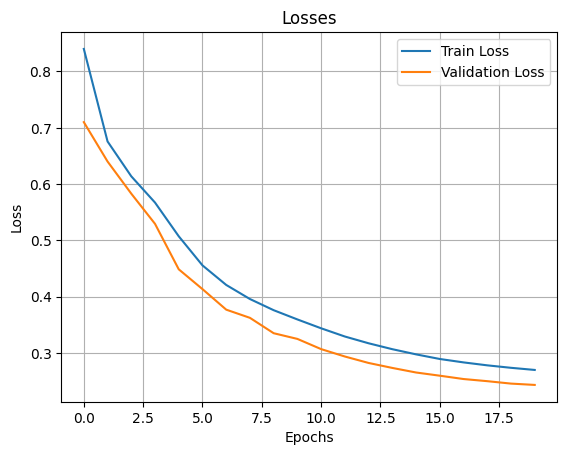

In [30]:
plot_losses(tr_loss, vl_loss)

# Fine-tuning the MAE Encoder as a Classifier

In [31]:
mae_model= MAE(
    image_size, patch_size, channels, mask_ratio, encoder_config=enc_config,
    decoder_config=dec_config, norm_pix_loss=False
).to(device)

# load the best model
best_val_loss= load_checkpoint(mae_model, device)

mae_model.decoder_embed= None  # discard the decoder side
mae_model.decoder= None
# --- Global Average Pooling (GAP) fine-tuning ---
# instead of classifying from the CLS token, we average the patch tokens (CLS excluded).
mae_model.encoder.pool= 'mean'
# the paper applies a LayerNorm ("fc_norm") to the pooled vector before the linear head
# the ViT has a 'latent_space' hook right after pooling, so we slot the fc_norm in there
mae_model.encoder.latent_space= nn.LayerNorm(enc_config.n_embed).to(device)

# create a fresh classification head and add it to lm_head of the encoder
n_classes= 10    # CIFAR-10 has 10 classes
fine_tune= True  # using the lightweight classification head
enc_head= MLPHead(
    enc_config.n_embed, enc_config.d_ff, n_classes, enc_config.dropout, fine_tune
).to(device)

mae_model.encoder.lm_head= enc_head
count_parameters(mae_model)

Checkpoint loaded from 'checkpoints/mae_model.pth'. Resuming training with best validation loss of 0.243517.
Number of parameters: 85,809,418


In [32]:
# train_loader has size 352, so 20 epochs have 7,040 steps
epochs= 20
steps= len(train_loader) * epochs
learning_rate= 3e-4

max_lr= learning_rate
min_lr= 3e-5
warmup_steps= steps * 0.1  # 2 epoch of warmup
max_steps= steps

optimizer= torch.optim.AdamW(
    mae_model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=0.1,
    fused=use_fused
)

criterion= nn.CrossEntropyLoss()
scheduler= CosineLRDecay(optimizer, min_lr, max_lr, warmup_steps, max_steps)
print(f"Using fused AdamW: {use_fused}")

Using fused AdamW: True


In [33]:
# fine-tuning on the pretrainig data; this is not ideal, but ok for now
# fine-tune on the full image: masking is a pretraining-only trick, and test_model() also uses
# mask_ratio=0.0, so training must match to avoid a train/eval distribution mismatch.
tr_loss, vl_loss, _= finetune_trainer(
    mae_model, 0.0, train_loader, val_loader, optimizer, criterion, scheduler, epochs,
    device, eval_interval=1, verbose=True
)

Epoch: 0 | Train Loss: 1.66006 | Val Loss: 1.23955 | lr: 7.5639e-05 | dt/epoch: 101773.08ms
Checkpoint saved | best_val_loss=1.239551 | saved at checkpoints/mae_model_ftn.pth
Epoch: 1 | Train Loss: 1.08560 | Val Loss: 0.94209 | lr: 2.2479e-04 | dt/epoch: 102324.73ms
Checkpoint saved | best_val_loss=0.942090 | saved at checkpoints/mae_model_ftn.pth
Epoch: 2 | Train Loss: 0.94252 | Val Loss: 0.92998 | lr: 2.9932e-04 | dt/epoch: 102184.52ms
Checkpoint saved | best_val_loss=0.929980 | saved at checkpoints/mae_model_ftn.pth
Epoch: 3 | Train Loss: 0.85153 | Val Loss: 0.91992 | lr: 2.9526e-04 | dt/epoch: 101424.44ms
Checkpoint saved | best_val_loss=0.919922 | saved at checkpoints/mae_model_ftn.pth
Epoch: 4 | Train Loss: 0.78048 | Val Loss: 0.77363 | lr: 2.8724e-04 | dt/epoch: 101769.61ms
Checkpoint saved | best_val_loss=0.773633 | saved at checkpoints/mae_model_ftn.pth
Epoch: 5 | Train Loss: 0.73158 | Val Loss: 0.72891 | lr: 2.7550e-04 | dt/epoch: 101800.19ms
Checkpoint saved | best_val_loss=

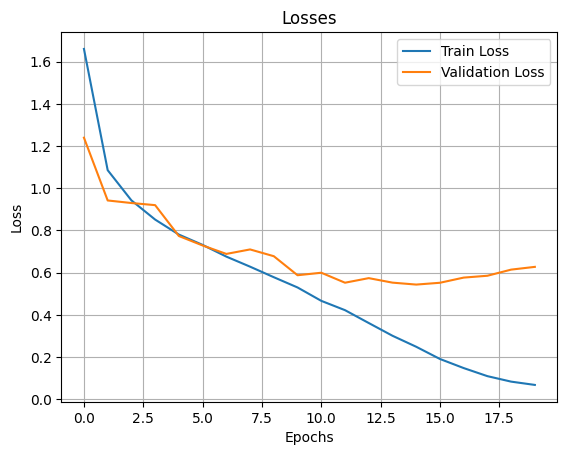

In [34]:
plot_losses(tr_loss, vl_loss)

In [35]:
mae_acc= test_model(mae_model, test_loader, device, verbose=True)

Accuracy: 84.38%


In [36]:
# https://ai.gopubby.com/the-ultimate-guide-to-masked-autoencoders-mae-87aa6883ff47
# https://medium.com/data-science/how-to-implement-state-of-the-art-masked-autoencoders-mae-6f454b736087
# https://github.com/facebookresearch/mae/tree/main